In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import os
from numba import jit
from IPython.display import display, clear_output

## Definition of Parameters


In [2]:
g_Na = 40.0
g_Cl = 7.5
g_K = 22.0

g_Na_space = np.linspace(g_Na - g_Na / 3, g_Na + g_Na / 3, 10)
g_Cl_space = np.linspace(g_Cl - g_Cl / 3, g_Cl + g_Cl / 3, 10)
g_K_space = np.linspace(g_K - g_K / 3, g_K + g_K / 3, 5)
kb_space = np.linspace(7.5, 17.5, 20)
  
params_grid = np.array(np.meshgrid(g_Na_space, g_Cl_space, g_K_space, kb_space)).T.reshape(-1, 4)



## Definition of the model

In [3]:
def Kbath_ode_model(params):
    t_init = 0
    t_final =10000
    dt = 0.01
    gamma = 0.04
    epsilon = 0.01
    ts = np.arange(t_init, t_final, dt)
    v_0 = -78.0
    n_inf = 1.0 / (1.0 + np.exp((-19.0 - v_0) / 18.0))
    z0 = np.array([-78.0, n_inf, -0.6, 0.8])
    Np = 10000
    t = np.linspace(0, Np, int(Np / 0.01))
    v = np.zeros_like(t)
    n = np.zeros_like(t)
    DK_i = np.zeros_like(t)
    Kg = np.zeros_like(t)
    Cm = 1.0
    tau_n = 0.25
    beta = 3.
    w_i = 2160.
    w_o = w_i / beta
    rho = 250.
    
    K_bath = params[3]

    Na_i0 = 16.0
    Na_o0 = 138.0
    K_i0 = 140.0
    K_o0 = 4.80
    Cl_o0 = 112.0
    Cl_i0 = 5.0
    g_Cl = params[1]
    g_Na = params[0]
    g_K = params[2]
    g_Nal = 0.02
    g_Kl = 0.12
    v[0] = z0[0]
    n[0] = z0[1]
    DK_i[0] = z0[2]
    Kg[0] = z0[3]

    for i in range(1, ts.shape[0]):
        # k1
        DNa_i = -DK_i[i-1]
        DNa_o = -beta * DNa_i
        DK_o = -beta * DK_i[i-1]
        K_i = K_i0 + DK_i[i-1]
        Na_i = Na_i0 + DNa_i
        Na_o = Na_o0 + DNa_o
        K_o = K_o0 + DK_o + Kg[i-1]

        m_inf = 1.0 / (1.0 + np.exp((-24.0 - v[i-1]) / 12.0))
        n_inf = 1.0 / (1.0 + np.exp((-19.0 - v[i-1]) / 18.0))
        h_n = 1.1 - 1.0 / (1.0 + np.exp(-8.0 * (n[i-1] - 0.4)))

        I_Na = (g_Nal + g_Na * m_inf * h_n) * (v[i-1] - 26.64 * np.log(Na_o / Na_i))
        I_K = (g_Kl + g_K * n[i-1]) * (v[i-1] - 26.64 * np.log(K_o / K_i))
        I_Cl = g_Cl * (v[i-1] + 26.64 * np.log(Cl_o0 / Cl_i0))
        I_pump = rho * (1.0 / (1.0 + np.exp((21.0 - Na_i) / 2.0))) * (1.0 / (1.0 + np.exp((5.5 - K_o))))

        k1_v = (-1.0 / Cm) * (I_Cl + I_Na + I_K + I_pump)
        k1_n = (n_inf - n[i-1]) / tau_n
        k1_DK_i = -(gamma / w_i) * (I_K - 2.0 * I_pump)
        k1_Kg = epsilon * (K_bath - K_o)

        # k2
        v_mid = v[i-1] + dt/2 * k1_v
        n_mid = n[i-1] + dt/2 * k1_n
        DK_i_mid = DK_i[i-1] + dt/2 * k1_DK_i
        Kg_mid = Kg[i-1] + dt/2 * k1_Kg

        DNa_i = -DK_i_mid
        DNa_o = -beta * DNa_i
        DK_o = -beta * DK_i_mid
        K_i = K_i0 + DK_i_mid
        Na_i = Na_i0 + DNa_i
        Na_o = Na_o0 + DNa_o
        K_o = K_o0 + DK_o + Kg_mid

        m_inf = 1.0 / (1.0 + np.exp((-24.0 - v_mid) / 12.0))
        n_inf = 1.0 / (1.0 + np.exp((-19.0 - v_mid) / 18.0))
        h_n = 1.1 - 1.0 / (1.0 + np.exp(-8.0 * (n_mid - 0.4)))

        I_Na = (g_Nal + g_Na * m_inf * h_n) * (v_mid - 26.64 * np.log(Na_o / Na_i))
        I_K = (g_Kl + g_K * n_mid) * (v_mid - 26.64 * np.log(K_o / K_i))
        I_Cl = g_Cl * (v_mid + 26.64 * np.log(Cl_o0 / Cl_i0))
        I_pump = rho * (1.0 / (1.0 + np.exp((21.0 - Na_i) / 2.0))) * (1.0 / (1.0 + np.exp((5.5 - K_o))))

        k2_v = (-1.0 / Cm) * (I_Cl + I_Na + I_K + I_pump)
        k2_n = (n_inf - n_mid) / tau_n
        k2_DK_i = -(gamma / w_i) * (I_K - 2.0 * I_pump)
        k2_Kg = epsilon * (K_bath - K_o)

        # k3
        v_mid = v[i-1] + dt/2 * k2_v
        n_mid = n[i-1] + dt/2 * k2_n
        DK_i_mid = DK_i[i-1] + dt/2 * k2_DK_i
        Kg_mid = Kg[i-1] + dt/2 * k2_Kg

        DNa_i = -DK_i_mid
        DNa_o = -beta * DNa_i
        DK_o = -beta * DK_i_mid
        K_i = K_i0 + DK_i_mid
        Na_i = Na_i0 + DNa_i
        Na_o = Na_o0 + DNa_o
        K_o = K_o0 + DK_o + Kg_mid

        m_inf = 1.0 / (1.0 + np.exp((-24.0 - v_mid) / 12.0))
        n_inf = 1.0 / (1.0 + np.exp((-19.0 - v_mid) / 18.0))
        h_n = 1.1 - 1.0 / (1.0 + np.exp(-8.0 * (n_mid - 0.4)))

        I_Na = (g_Nal + g_Na * m_inf * h_n) * (v_mid - 26.64 * np.log(Na_o / Na_i))
        I_K = (g_Kl + g_K * n_mid) * (v_mid - 26.64 * np.log(K_o / K_i))
        I_Cl = g_Cl * (v_mid + 26.64 * np.log(Cl_o0 / Cl_i0))
        I_pump = rho * (1.0 / (1.0 + np.exp((21.0 - Na_i) / 2.0))) * (1.0 / (1.0 + np.exp((5.5 - K_o))))

        k3_v = (-1.0 / Cm) * (I_Cl + I_Na + I_K + I_pump)
        k3_n = (n_inf - n_mid) / tau_n
        k3_DK_i = -(gamma / w_i) * (I_K - 2.0 * I_pump)
        k3_Kg = epsilon * (K_bath - K_o)

        # k4
        v_end = v[i-1] + dt * k3_v
        n_end = n[i-1] + dt * k3_n
        DK_i_end = DK_i[i-1] + dt * k3_DK_i
        Kg_end = Kg[i-1] + dt * k3_Kg

        DNa_i = -DK_i_end
        DNa_o = -beta * DNa_i
        DK_o = -beta * DK_i_end
        K_i = K_i0 + DK_i_end
        Na_i = Na_i0 + DNa_i
        Na_o = Na_o0 + DNa_o
        K_o = K_o0 + DK_o + Kg_end

        m_inf = 1.0 / (1.0 + np.exp((-24.0 - v_end) / 12.0))
        n_inf = 1.0 / (1.0 + np.exp((-19.0 - v_end) / 18.0))
        h_n = 1.1 - 1.0 / (1.0 + np.exp(-8.0 * (n_end - 0.4)))

        I_Na = (g_Nal + g_Na * m_inf * h_n) * (v_end - 26.64 * np.log(Na_o / Na_i))
        I_K = (g_Kl + g_K * n_end) * (v_end - 26.64 * np.log(K_o / K_i))
        I_Cl = g_Cl * (v_end + 26.64 * np.log(Cl_o0 / Cl_i0))
        I_pump = rho * (1.0 / (1.0 + np.exp((21.0 - Na_i) / 2.0))) * (1.0 / (1.0 + np.exp((5.5 - K_o))))

        k4_v = (-1.0 / Cm) * (I_Cl + I_Na + I_K + I_pump)
        k4_n = (n_inf - n_end) / tau_n
        k4_DK_i = -(gamma / w_i) * (I_K - 2.0 * I_pump)
        k4_Kg = epsilon * (K_bath - K_o)

        # Aggiornamento delle variabili con RK4
        v[i] = v[i-1] + (dt/6) * (k1_v + 2*k2_v + 2*k3_v + k4_v)
        n[i] = n[i-1] + (dt/6) * (k1_n + 2*k2_n + 2*k3_n + k4_n)
        DK_i[i] = DK_i[i-1] + (dt/6) * (k1_DK_i + 2*k2_DK_i + 2*k3_DK_i + k4_DK_i)
        Kg[i] = Kg[i-1] + (dt/6) * (k1_Kg + 2*k2_Kg + 2*k3_Kg + k4_Kg)

    return v, n, DK_i, Kg

## JIT Compilation of the ODE Model with Numba


In [9]:
# Applies just-in-time (JIT) compilation to the Kbath_ode_model function
# This optimizes the function for faster execution using Numba
Kbath_ode_model_jit = jit(Kbath_ode_model)

## Interactive Interface for Navigating and Classifying ODE Model Outputs


In [ ]:
def create_interactive_interface(filename, ode_model, params_grid, param_names, categories):

    # Ensure param_names and param values match
    assert all(len(p) == len(param_names) for p in params_grid), "Mismatch between param_names and params_grid dimensions"

    # Check if the file already exists
    if os.path.exists(filename):
        mode = 'a'
        with open(filename, 'r') as f:
            lines = f.readlines()
        current_index = len(lines) - 1 if len(lines) > 1 else 0
    else:
        mode = 'w'
        current_index = 0

    # Write header if new file
    if mode == 'w':
        with open(filename, 'w') as f:
            f.write("\t".join(param_names) + "\tCategory\n")

    state = {'index': current_index}

    # Plot update function
    def update_plot():
        clear_output(wait=True)

        params = params_grid[state['index']]
        result = ode_model(params)[0]

        current_index = state['index'] + 1
        total_params = len(params_grid)

        fig = plt.figure(figsize=(10, 8))
        plt.subplot(311)
        plt.plot(range(len(result)), result)

        # Generate LaTeX-style title with parameter values
        title_str = ", ".join(
            [f"${{{name}}} = {val:.2f}$" for name, val in zip(param_names, params)]
        )
        plt.title(rf"{title_str}  ({current_index}/{total_params})")
        plt.xlabel("Time / Step")
        plt.ylabel("Model Output")
        plt.grid()
        plt.show()

        display(buttons_box, categories_box)

    # Previous callback
    def on_previous_clicked(b):
        if state['index'] > 0:
            state['index'] -= 1
            with open(filename, 'r+') as f:
                lines = f.readlines()
                f.seek(0)
                f.writelines(lines[:-1])
                f.truncate()
            update_plot()
        else:
            print("It's the first value")


    # Category click handler
    def on_category_clicked(category):
        params = params_grid[state['index']]
        with open(filename, 'a') as f:
            f.write("\t".join(f"{p}" for p in params) + f"\t{category}\n")
        print(f"Saved: {category}")
        if state['index'] < len(params_grid) - 1:
            state['index'] += 1
            update_plot()
        else:
            print("It's the last value")

    # Buttons
    button_previous = widgets.Button(description="Previous", layout=widgets.Layout(width="120px", height="40px"))
    button_previous.on_click(on_previous_clicked)


    # Create buttons for each category
    category_buttons = []
    for cat in categories:
        btn = widgets.Button(description=cat, layout=widgets.Layout(width="250px", height="40px"))
        btn.on_click(lambda b, c=cat: on_category_clicked(c))
        category_buttons.append(btn)

    # Layout for navigation button and category buttons
    buttons_box = widgets.HBox([button_previous])
    categories_box = widgets.GridBox(
        category_buttons,
        layout=widgets.Layout(grid_template_columns="repeat(3, 250px)", grid_gap="10px")
    )

    # Display the interface
    display(buttons_box, categories_box)
    update_plot()


## Application to the Current ODE Model


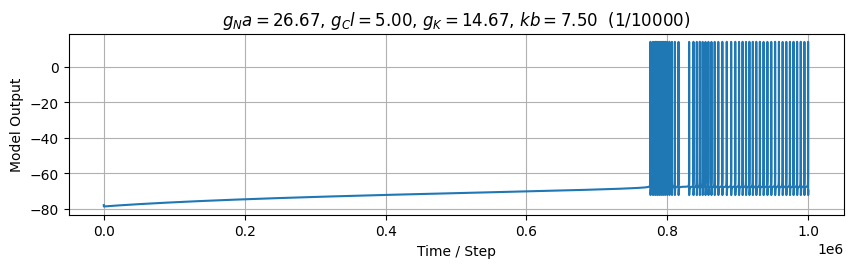

GridBox(children=(Button(description='no signal', layout=Layout(height='40px', width='250px'), style=ButtonSty…

In [11]:
param_names = ["g_Na", "g_Cl", "g_K", "kb"]
categories = ["no signal", "SNIC-SNIC", "SNIC-Infinity", "SN-SH", "SN-Infinity",
              "SN-SupH | Sup H - SH", "SN-SupH | Sup H - Infinity", "SN-SupH", "SNIC-SH", "SNIC-SupH"]

create_interactive_interface("class_output.txt", Kbath_ode_model_jit, params_grid, param_names, categories)
